In [1]:
%config InlineBackend.figure_formats = {"retina", "png"}
%matplotlib inline

In [2]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
import tempfile
from datetime import datetime

from IPython.display import HTML, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import h5py

import tdgl
from tdgl.geometry import box, circle

In [3]:
tempdir = tempfile.TemporaryDirectory(dir=os.getcwd())

# ─────────────────────────────────────────────
# CARPETAS DE RESULTADOS
# Cambiar "geometria_1" por "geometria_2", etc. según la simulación
# ─────────────────────────────────────────────
carpeta_resultados = "Resultados"
carpeta_geometria  = "geometria_1"   # <-- CAMBIAR AQUÍ para cada geometría
factor_escala = 0.5

ruta_geometria = os.path.join(carpeta_resultados, carpeta_geometria)
os.makedirs(ruta_geometria, exist_ok=True)

print(f"Carpeta de resultados: {ruta_geometria}")

Carpeta de resultados: Resultados/geometria_1


# Definición de parámetros del material y de la geometría de peine asimétrico

La geometría sigue la Ec. (1) del paper:
$$y(x) = -h_d \sum_{i=1}^{N} \exp\left(-\frac{(x - x_i)^2}{2\delta^2}\right)$$

donde:
- $h_d$ = profundidad máxima de los dientes
- $x_i$ = posición central del i-ésimo diente
- $\delta = 0.20 \cdot \Delta x$ = parámetro de suavidad geométrica
- $N$ = número de dientes (controla la densidad del peine)

In [4]:
length_units = "um"

# ─────────────────────────────────────────────
# PARÁMETROS DEL MATERIAL (sin cambios)
# ─────────────────────────────────────────────
xi            = 0.5   # Longitud de coherencia (µm)
london_lambda = 2     # Longitud de penetración de London (µm)
d             = 0.1   # Espesor de la lámina (µm)
gamma         = 1     # Parámetro de amortiguamiento

layer = tdgl.Layer(
    coherence_length=xi,
    london_lambda=london_lambda,
    thickness=d,
    gamma=gamma
)

# ─────────────────────────────────────────────
# PARÁMETROS GEOMÉTRICOS GLOBALES DEL DISPOSITIVO
# Según el paper: Lx = 20 µm, Ly = 5 µm, Lz = 0.1 µm
# ─────────────────────────────────────────────
total_length = 20.0 * factor_escala   # Lx: longitud total del dispositivo (µm)
total_width  = 5.0  * factor_escala  # Ly: altura del bloque rectangular base (µm)

# ─────────────────────────────────────────────
# PARÁMETROS DE LOS DIENTES GAUSSIANOS (Ec. 1 del paper)
# ─────────────────────────────────────────────
N  = 8      # Número de dientes (probar: 4, 8, 12, 16)
hd = 3.5 * factor_escala   # Profundidad máxima de cada diente (µm)
            # Nota: hd < total_width para que el dispositivo no quede cerrado

# Separación entre dientes: se distribuyen uniformemente a lo largo de Lx
delta_x = total_length / N          # Separación entre centros de dientes (µm)
delta   = 0.20 * delta_x            # Parámetro de suavidad geométrica (δ = 0.20·Δx)

# Posiciones centrales de cada diente xi, distribuidas uniformemente
x_teeth = np.linspace(
    -total_length / 2 + delta_x / 2,
     total_length / 2 - delta_x / 2,
    N
)

# ─────────────────────────────────────────────
# PARÁMETROS DE LOS CONTACTOS METÁLICOS
# Según el paper: longitud de contacto d = 2.0 µm
# ─────────────────────────────────────────────
contact_length = 2.0 * factor_escala   # Longitud de los contactos metálicos source/drain (µm)
contact_width  = 0.1   # Ancho del contacto en x (µm, muy delgado)

# ─────────────────────────────────────────────
# CORRIENTE DE SIMULACIÓN INICIAL
# ─────────────────────────────────────────────
corriente_inicial = 12   # Corriente inyectada en la simulación de prueba (µA)

# ─────────────────────────────────────────────
# BARRIDO DE CORRIENTE
# ─────────────────────────────────────────────
corriente_min  = 0.0    # Corriente mínima del barrido (µA)
corriente_max  = 50.0   # Corriente máxima del barrido (µA)
corriente_paso = 0.1    # Paso del barrido (µA)

print(f"Número de dientes        N     = {N}")
print(f"Separación entre dientes Δx   = {delta_x:.3f} µm")
print(f"Parámetro de suavidad    δ    = {delta:.3f} µm")
print(f"Profundidad de dientes   hd   = {hd} µm")
print(f"Pared restante (Ly - hd)      = {total_width - hd} µm")
print(f"Longitud contactos            = {contact_length} µm")
print(f"Posiciones xi = {np.round(x_teeth, 2)}")

# ─────────────────────────────────────────────
# FUNCIÓN DEL PERFIL DEL BORDE INFERIOR (Ec. 1)
# y(x) = -hd * Σ exp(-(x - xi)^2 / (2δ^2))
# ─────────────────────────────────────────────
def lower_edge_profile(x, hd, x_teeth, delta):
    """Perfil del borde inferior con dientes gaussianos (Ec. 1 del paper)."""
    y = np.zeros_like(x, dtype=float)
    for xi_i in x_teeth:
        y += -hd * np.exp(-((x - xi_i) ** 2) / (2 * delta ** 2))
    return y

# ─────────────────────────────────────────────
# CONSTRUCCIÓN DEL POLÍGONO DE PEINE ASIMÉTRICO
# El polígono recorre: borde superior (recto) → lado derecho →
#   borde inferior con dientes → lado izquierdo → cierre
# ─────────────────────────────────────────────
n_points = 1000  # Resolución del borde inferior (más puntos = dientes más suaves)

x_bottom = np.linspace(-total_length / 2, total_length / 2, n_points)
y_bottom = lower_edge_profile(x_bottom, hd, x_teeth, delta)

y_top    =  total_width / 2
y_base   = -total_width / 2

y_bottom_coords = y_base + y_bottom

x_top_edge   = np.array([-total_length/2, total_length/2])
y_top_edge   = np.array([y_top, y_top])
x_right_edge = np.array([total_length/2, total_length/2])
y_right_edge = np.array([y_top, y_base])
x_bot_rev    = x_bottom[::-1]
y_bot_rev    = y_bottom_coords[::-1]
x_left_edge  = np.array([-total_length/2, -total_length/2])
y_left_edge  = np.array([y_base, y_top])

x_polygon = np.concatenate([x_top_edge, x_right_edge, x_bot_rev, x_left_edge])
y_polygon = np.concatenate([y_top_edge, y_right_edge, y_bot_rev, y_left_edge])
polygon_points = np.column_stack([x_polygon, y_polygon])

# ─────────────────────────────────────────────
# FILM: Polígono de peine asimétrico
# ─────────────────────────────────────────────
film = (
    tdgl.Polygon("film", points=polygon_points)
    .resample(1200)
    .buffer(0)
)

# ─────────────────────────────────────────────
# TERMINALES: Source (izquierda) y Drain (derecha)
# ─────────────────────────────────────────────
source = (
    tdgl.Polygon("source", points=box(contact_width, contact_length))
    .translate(dx=-total_length / 2)
)
drain = source.scale(xfact=-1).set_name("drain")

# ─────────────────────────────────────────────
# PUNTOS DE MEDICIÓN DE VOLTAJE
# ─────────────────────────────────────────────
probe_points = [
    (-total_length / 2.5, 0),
     (total_length / 2.5, 0)
]

# ─────────────────────────────────────────────
# DEFINICIÓN DEL DISPOSITIVO
# ─────────────────────────────────────────────
device = tdgl.Device(
    "peine_asimetrico",
    layer=layer,
    film=film,
    terminals=[source, drain],
    probe_points=probe_points,
    length_units=length_units,
)

print("\nDispositivo creado correctamente.")

Número de dientes        N     = 8
Separación entre dientes Δx   = 1.250 µm
Parámetro de suavidad    δ    = 0.250 µm
Profundidad de dientes   hd   = 1.75 µm
Pared restante (Ly - hd)      = 0.75 µm
Longitud contactos            = 1.0 µm
Posiciones xi = [-4.38 -3.12 -1.88 -0.62  0.62  1.88  3.12  4.38]

Dispositivo creado correctamente.


In [5]:
# ─────────────────────────────────────────────
# GUARDAR TXT CON PARÁMETROS DE LA SIMULACIÓN
# Se guarda en Resultados/geometria_1/parametros.txt
# Al final del notebook se añade la corriente crítica encontrada
# ─────────────────────────────────────────────
ruta_txt = os.path.join(ruta_geometria, "parametros.txt")

with open(ruta_txt, "w", encoding="utf-8") as f:
    f.write("=" * 50 + "\n")
    f.write("PARÁMETROS DE SIMULACIÓN\n")
    f.write(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Geometría: {carpeta_geometria}\n")
    f.write("=" * 50 + "\n\n")

    f.write("--- MATERIAL ---\n")
    f.write(f"xi (coherencia)          = {xi} µm\n")
    f.write(f"london_lambda            = {london_lambda} µm\n")
    f.write(f"d (espesor)              = {d} µm\n")
    f.write(f"gamma                    = {gamma}\n\n")

    f.write("--- GEOMETRÍA DEL DISPOSITIVO ---\n")
    f.write(f"Lx (longitud total)      = {total_length} µm\n")
    f.write(f"Ly (altura bloque)       = {total_width} µm\n")
    f.write(f"Lz (espesor)             = {d} µm\n\n")

    f.write("--- DIENTES GAUSSIANOS (Ec. 1 del paper) ---\n")
    f.write(f"N (número de dientes)    = {N}\n")
    f.write(f"hd (profundidad diente)  = {hd} µm\n")
    f.write(f"Pared restante (Ly-hd)   = {total_width - hd} µm\n")
    f.write(f"delta_x (sep. dientes)   = {delta_x:.4f} µm\n")
    f.write(f"delta (suavidad)         = {delta:.4f} µm\n")
    f.write(f"Posiciones xi            = {np.round(x_teeth, 4).tolist()} µm\n\n")

    f.write("--- CONTACTOS ---\n")
    f.write(f"contact_length           = {contact_length} µm\n")
    f.write(f"contact_width            = {contact_width} µm\n\n")

    f.write("--- CORRIENTES ---\n")
    f.write(f"Corriente simulación inicial = {corriente_inicial} µA\n")
    f.write(f"Barrido: de {corriente_min} a {corriente_max} µA en pasos de {corriente_paso} µA\n\n")

    f.write("--- MALLA ---\n")
    f.write(f"max_edge_length          = xi/2 = {xi/2} µm\n")
    f.write(f"smooth                   = 100\n")
    f.write(f"n_points borde inferior  = {n_points}\n")

print(f"Parámetros guardados en: {ruta_txt}")

Parámetros guardados en: Resultados/geometria_1/parametros.txt


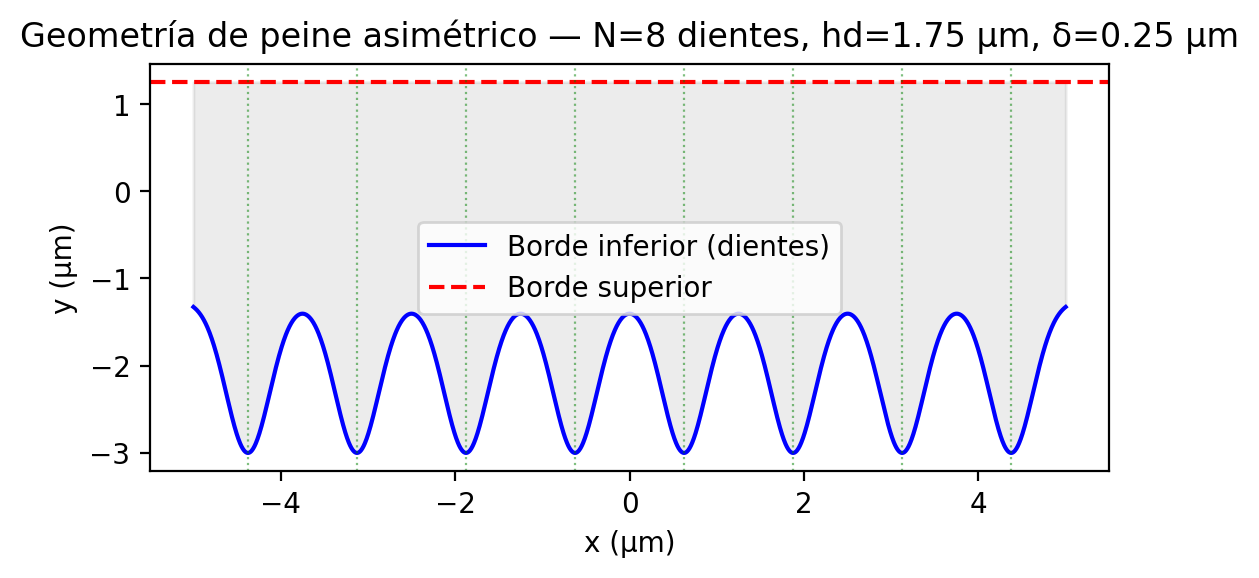

In [6]:
# Visualizar el perfil del borde inferior
fig, ax = plt.subplots(figsize=(10, 3))
x_plot = np.linspace(-total_length / 2, total_length / 2, 2000)
y_plot = y_base + lower_edge_profile(x_plot, hd, x_teeth, delta)
ax.plot(x_plot, y_plot, 'b-', label='Borde inferior (dientes)')
ax.axhline(y_top, color='r', linestyle='--', label='Borde superior')
ax.fill_between(x_plot, y_plot, y_top, alpha=0.15, color='gray')
for xi_i in x_teeth:
    ax.axvline(xi_i, color='g', linestyle=':', alpha=0.5, linewidth=0.8)
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_title(f'Geometría de peine asimétrico — N={N} dientes, hd={hd} µm, δ={delta:.2f} µm')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
fig.savefig(os.path.join(ruta_geometria, "perfil_borde_inferior.png"), dpi=150)
plt.show()

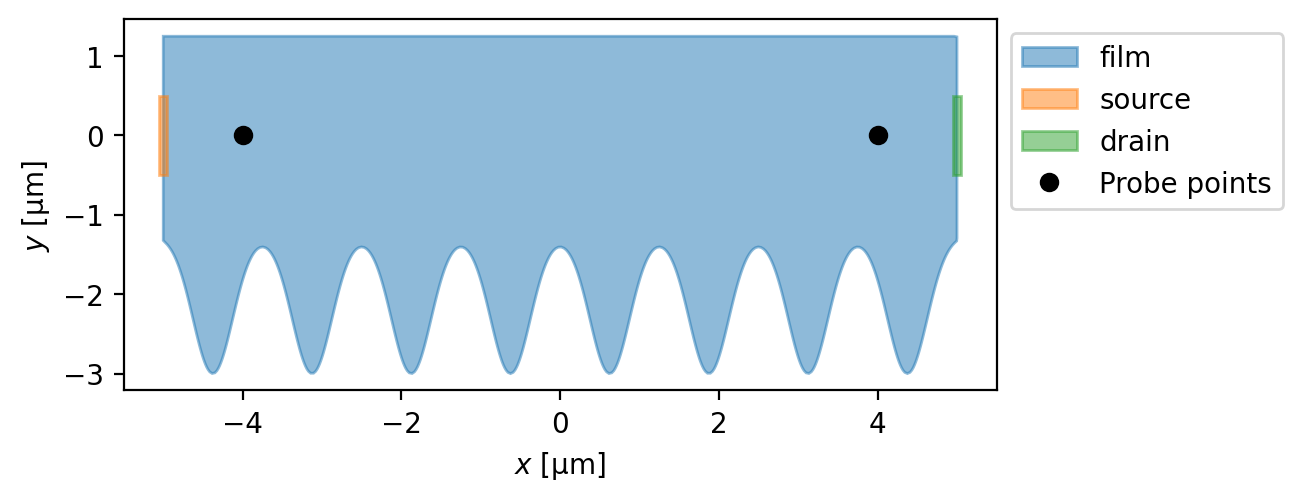

In [7]:
# Dibujar el dispositivo con tdgl
fig, ax = device.draw()
fig.savefig(os.path.join(ruta_geometria, "dispositivo.png"), dpi=150)
plt.show()

In [8]:
# ─────────────────────────────────────────────
# OPCIONES DEL SOLVER (sin cambios)
# ─────────────────────────────────────────────
options = tdgl.SolverOptions(
    skip_time=100,
    solve_time=200,
    output_file=os.path.join(tempdir.name, "campo_corriente_peine.h5"),
    field_units="mT",
    current_units="uA",
    save_every=100,
)

Constructing Voronoi polygons: 100%|██████████| 5312/5312 [00:00<00:00, 11027.21it/s]


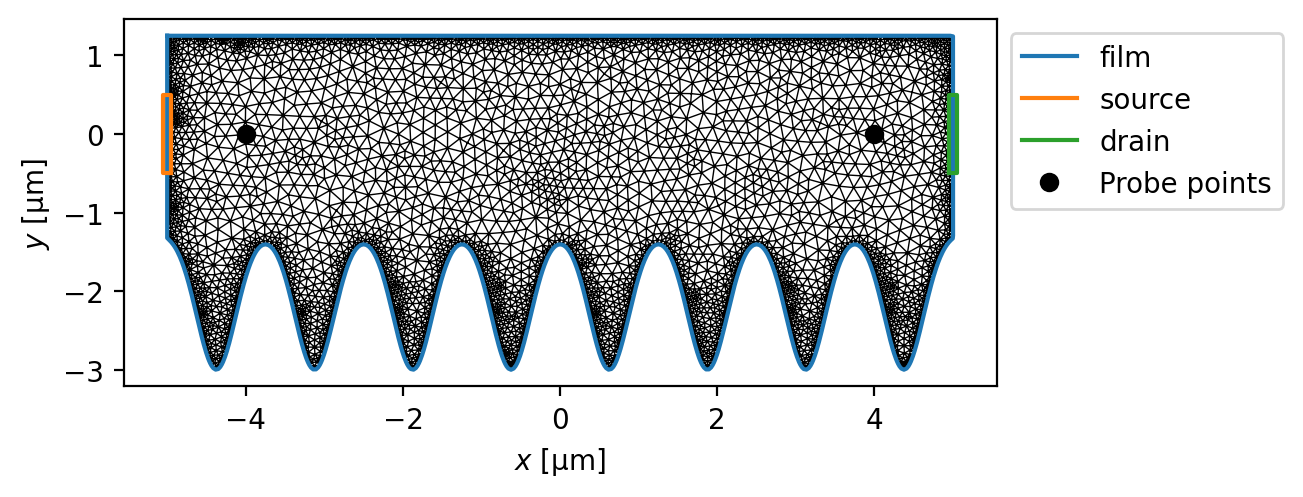

In [9]:
# Generar la malla del dispositivo
device.make_mesh(max_edge_length=xi / 2, smooth=100)
fig, ax = device.plot(mesh=True, legend=True)
fig.savefig(os.path.join(ruta_geometria, "malla.png"), dpi=150)
plt.show()

# Simulación de las corrientes en el superconductor de peine

- I = 12 µA
- H = 0

Simulating: 100%|██████████| 200/200 [00:30<00:00,  6.46tau/s ]


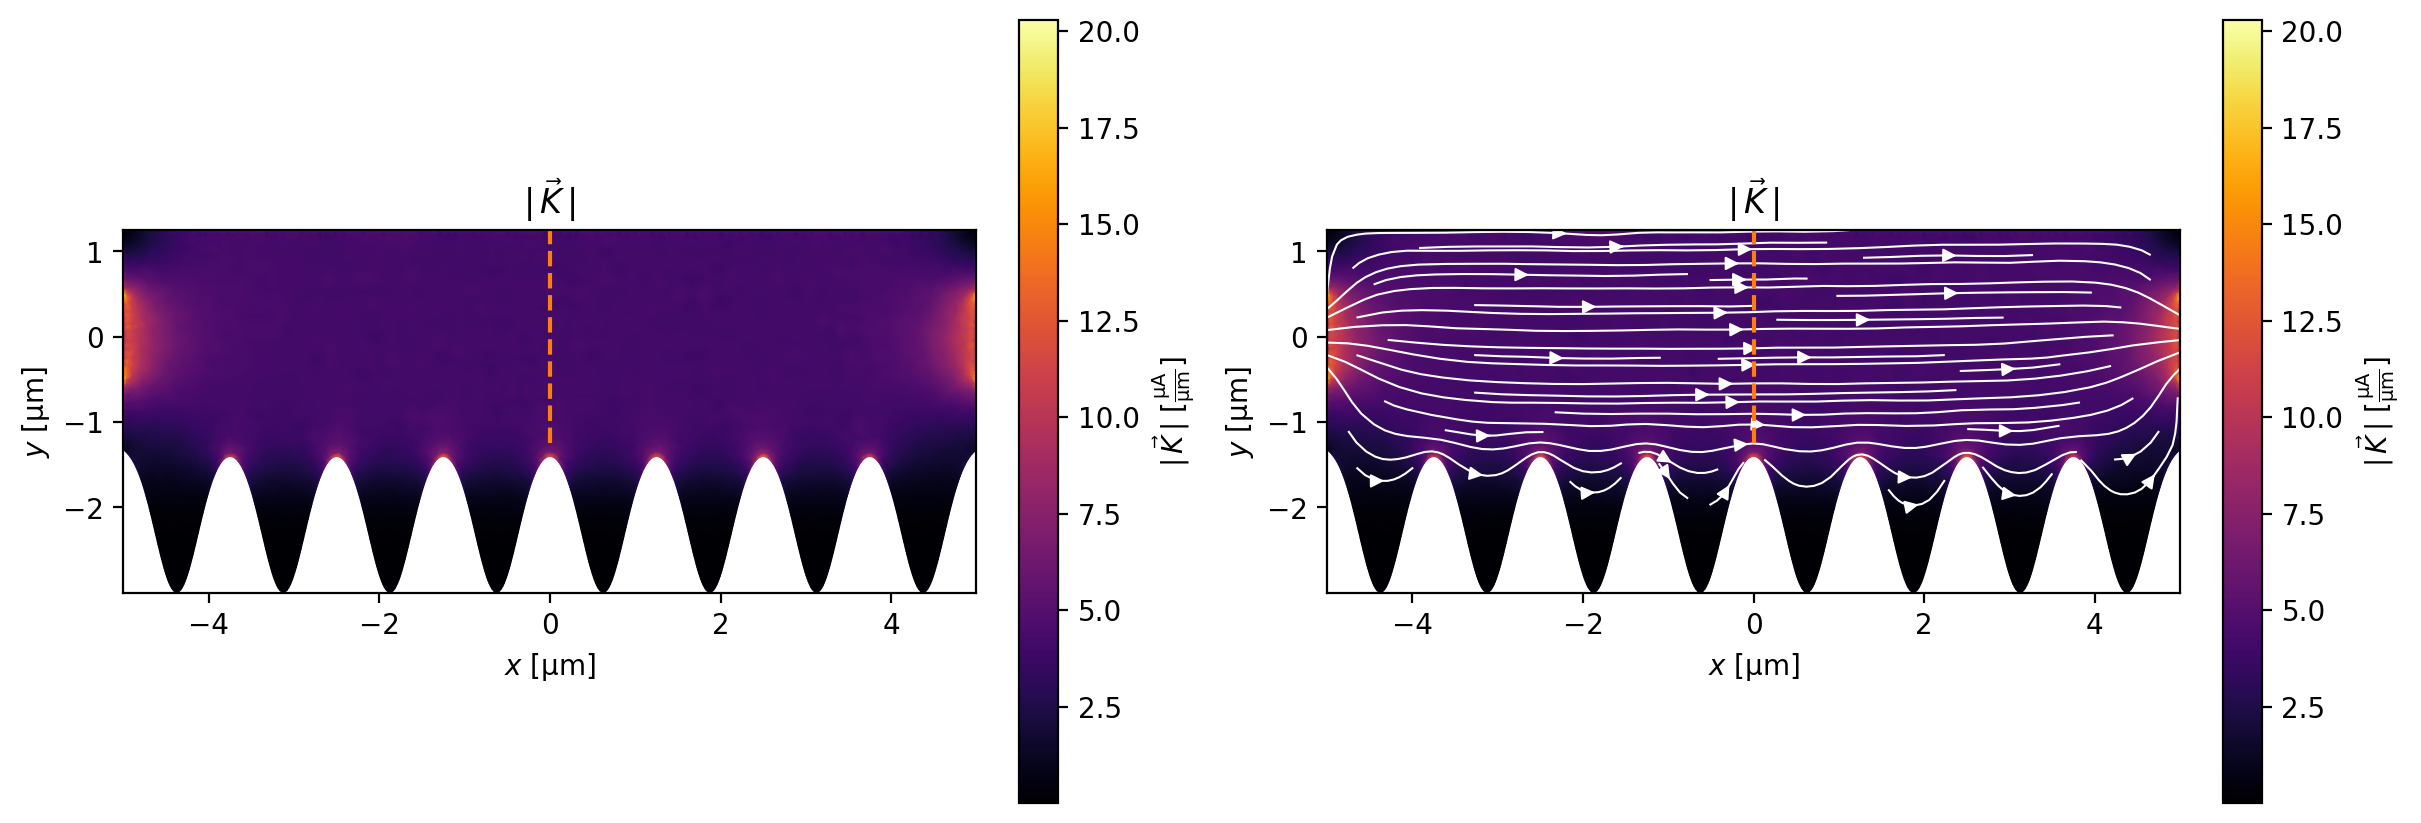

Corriente medida: 10.431 µA


In [10]:
default_terminal_currents = {
    'source':  corriente_inicial,
    'drain':  -corriente_inicial
}

H_zero_solution = tdgl.solve(
    device=device,
    options=options,
    terminal_currents=default_terminal_currents
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
_ = H_zero_solution.plot_currents(ax=axes[0], streamplot=False)
_ = H_zero_solution.plot_currents(ax=axes[1])

# Sección transversal vertical en el centro del dispositivo
y_cross = np.linspace(-total_width / 2, total_width / 2, 401)
x_cross = np.zeros_like(y_cross)
cross_section = np.array([x_cross, y_cross]).T

for ax in axes:
    _ = ax.plot(x_cross, y_cross, "C1--")

fig.savefig(os.path.join(ruta_geometria, "corrientes_simulacion.png"), dpi=150)
plt.show()

current = H_zero_solution.current_through_path(cross_section)
print(f"Corriente medida: {current:.3f~P}")

# Densidad de pares de Cooper |ψ|²

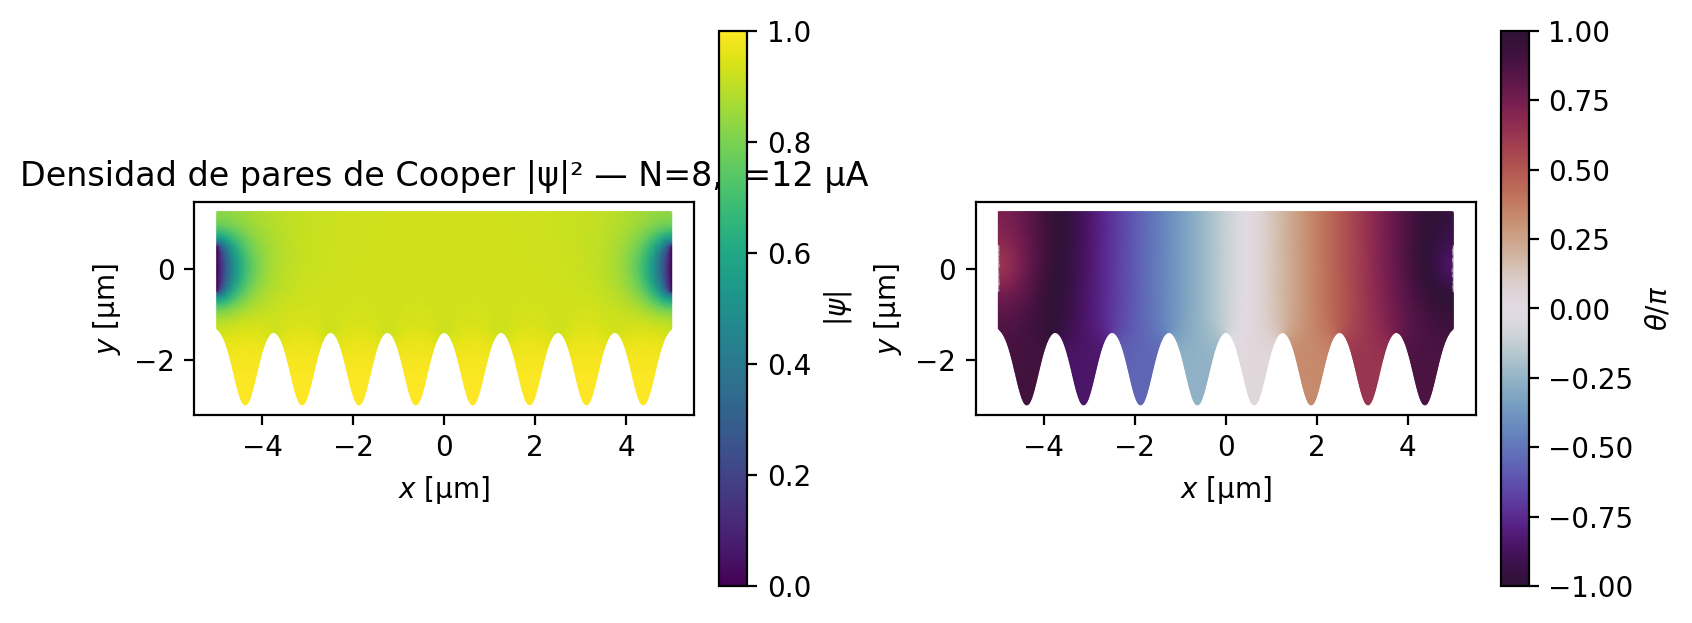

In [11]:
# Gráfica de la densidad de pares de Cooper
fig, axes = H_zero_solution.plot_order_parameter()
axes.flat[0].set_title(f'Densidad de pares de Cooper |ψ|² — N={N}, I={corriente_inicial} µA')
fig.savefig(os.path.join(ruta_geometria, "densidad_pares_cooper.png"), dpi=150)
plt.show()

In [12]:
%%time
# ─────────────────────────────────────────────
# BARRIDO DE CORRIENTE: Curva V vs I
# ─────────────────────────────────────────────
def get_mean_voltage(device, options, current):
    terminal_currents = {
        'source':  current,
        'drain':  -current
    }
    solution = tdgl.solve(
        device=device,
        options=options,
        terminal_currents=terminal_currents
    )
    voltage = solution.dynamics.mean_voltage()
    return voltage

currents    = np.arange(corriente_min, corriente_max, corriente_paso)
voltages    = []
intensities = []

csv_path = os.path.join(ruta_geometria, "V_vs_I_peine.csv")

if os.path.exists(csv_path):
    os.remove(csv_path)

for current in currents:
    voltage = get_mean_voltage(device=device, options=options, current=current)
    voltages.append(voltage)
    intensities.append(current)

    csv_df = pd.DataFrame({'current_µA': [current], 'voltage_V': [voltage]})
    csv_df.to_csv(csv_path, mode='a', header=not os.path.exists(csv_path), index=False)

Output file already exists. Renaming to /home/sergio/Documentos/Congreso/Programa 3/tmpu_f7ath6/campo_corriente_peine-1.h5.
Simulating: 100%|█████████▉| 200/200 [00:13<00:00, 14.42tau/s ]
Output file already exists. Renaming to /home/sergio/Documentos/Congreso/Programa 3/tmpu_f7ath6/campo_corriente_peine-2.h5.
Simulating: 100%|█████████▉| 200/200 [00:31<00:00,  6.36tau/s ]
Output file already exists. Renaming to /home/sergio/Documentos/Congreso/Programa 3/tmpu_f7ath6/campo_corriente_peine-3.h5.
Simulating: 100%|██████████| 200/200 [00:31<00:00,  6.43tau/s ]
Output file already exists. Renaming to /home/sergio/Documentos/Congreso/Programa 3/tmpu_f7ath6/campo_corriente_peine-4.h5.
Simulating: 100%|█████████▉| 200/200 [00:31<00:00,  6.27tau/s ]
Output file already exists. Renaming to /home/sergio/Documentos/Congreso/Programa 3/tmpu_f7ath6/campo_corriente_peine-5.h5.
Simulating: 100%|██████████| 200/200 [00:32<00:00,  6.20tau/s ]
Output file already exists. Renaming to /home/sergio/Documen

CPU times: user 7h 53s, sys: 1min 56s, total: 7h 2min 50s
Wall time: 7h 3min 11s


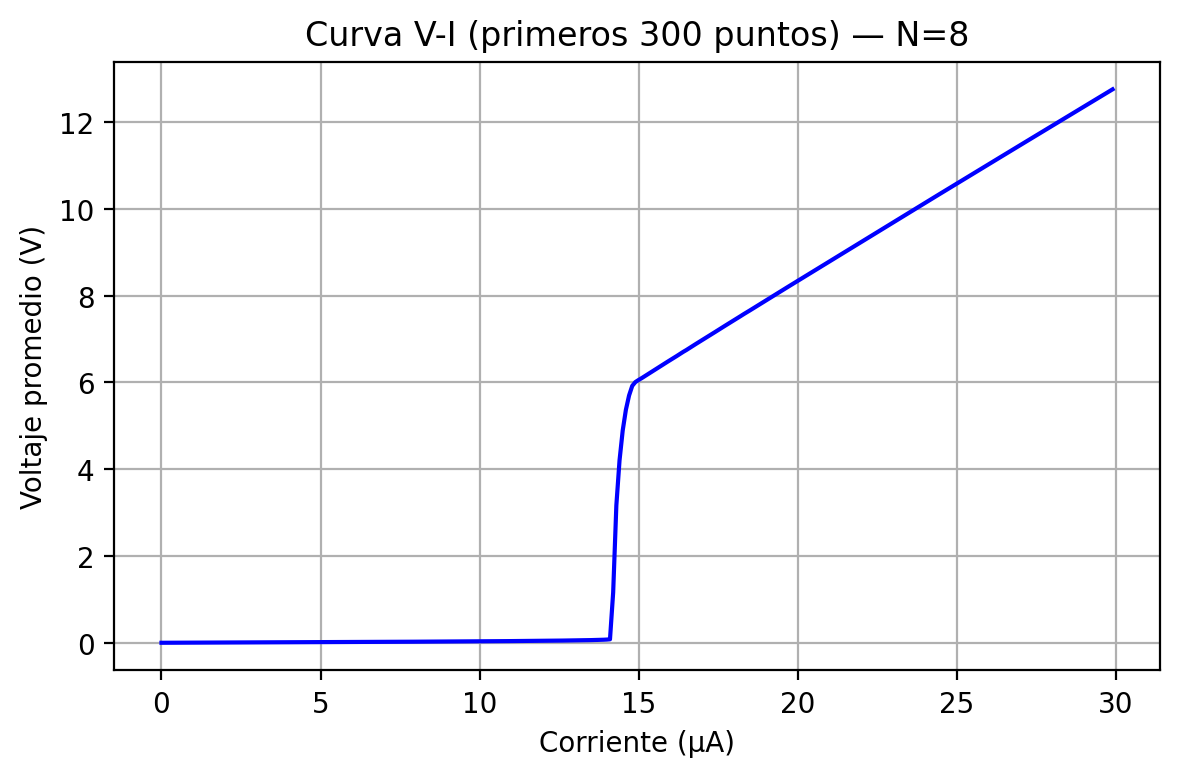

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(intensities[:300], voltages[:300], linestyle='-', color='blue')
plt.xlabel('Corriente (µA)')
plt.ylabel('Voltaje promedio (V)')
plt.title(f'Curva V-I (primeros 300 puntos) — N={N}')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(ruta_geometria, "curva_VI_300puntos.png"), dpi=150)
plt.show()

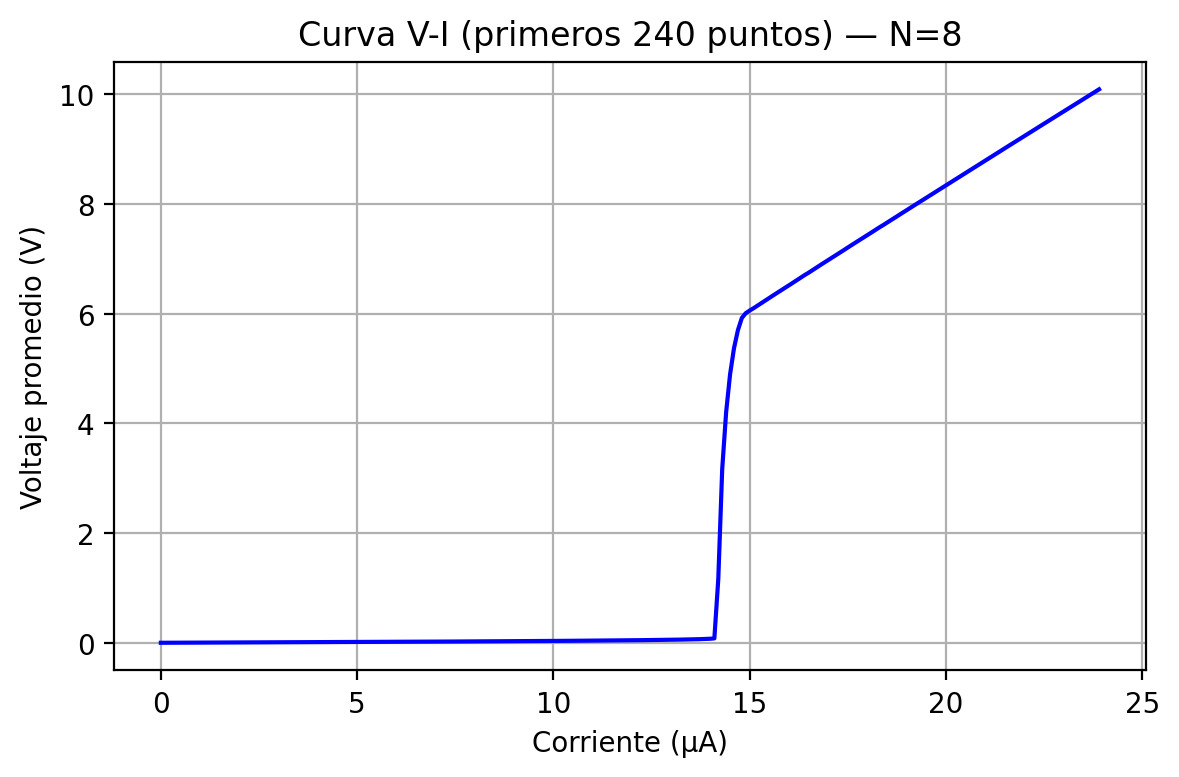

In [15]:
plt.figure(figsize=(6, 4))
plt.plot(intensities[:240], voltages[:240], color='blue')
plt.xlabel('Corriente (µA)')
plt.ylabel('Voltaje promedio (V)')
plt.title(f'Curva V-I (primeros 240 puntos) — N={N}')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(ruta_geometria, "curva_VI_240puntos.png"), dpi=150)
plt.show()

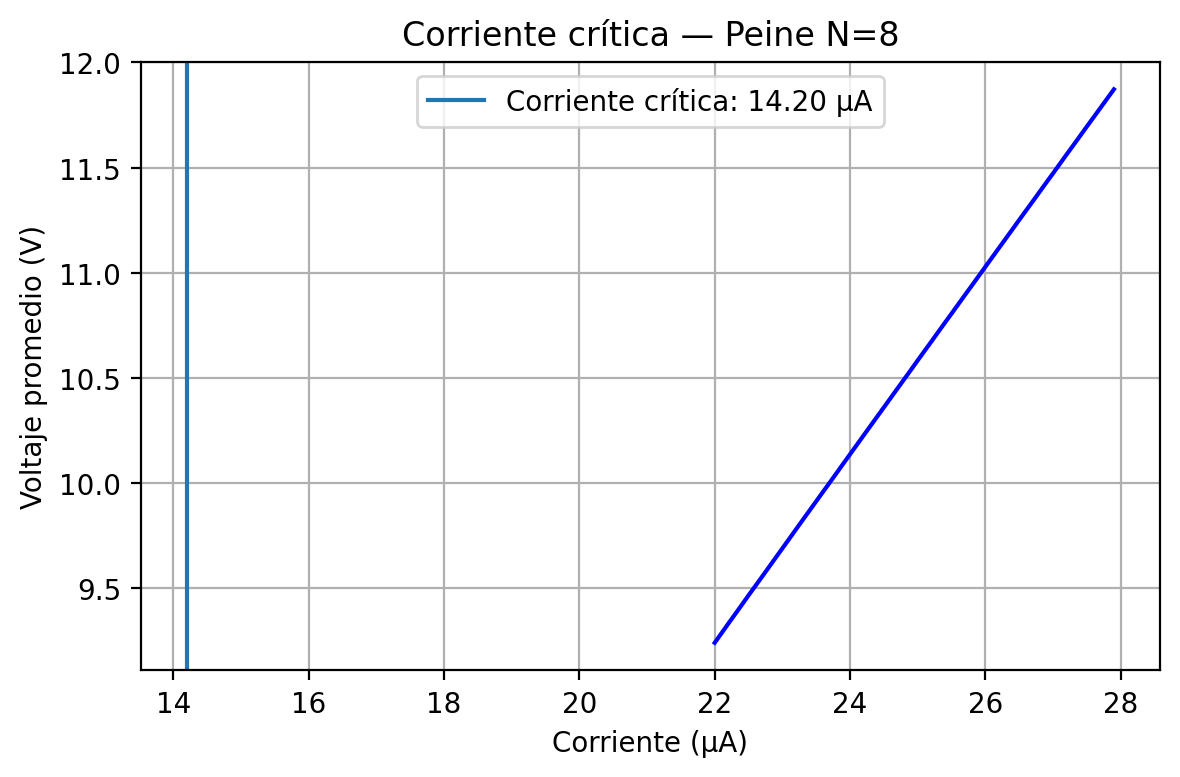

Corriente crítica estimada: 14.20 µA


In [16]:
# ─────────────────────────────────────────────
# DETECCIÓN DE LA CORRIENTE CRÍTICA
# Criterio: mayor salto (gap) consecutivo en voltaje
# ─────────────────────────────────────────────
critical_current = 0
biggest_gap = 0

for i in range(len(voltages) - 1):
    tmp_gap = voltages[i + 1] - voltages[i]
    if tmp_gap > biggest_gap:
        biggest_gap = tmp_gap
        critical_current = i

plt.figure(figsize=(6, 4))
plt.plot(intensities[220:280], voltages[220:280], linestyle='-', color='blue')
plt.axvline(
    currents[critical_current],
    label=f'Corriente crítica: {currents[critical_current]:.2f} µA'
)
plt.xlabel('Corriente (µA)')
plt.ylabel('Voltaje promedio (V)')
plt.title(f'Corriente crítica — Peine N={N}')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(ruta_geometria, "corriente_critica.png"), dpi=150)
plt.show()

print(f"Corriente crítica estimada: {currents[critical_current]:.2f} µA")

# Añadir la corriente crítica encontrada al txt de parámetros
with open(ruta_txt, "a", encoding="utf-8") as f:
    f.write("\n--- RESULTADO ---\n")
    f.write(f"Corriente crítica estimada = {currents[critical_current]:.2f} µA\n")